Что нужно сделать:
1. Загрузи и изучи данные. Размер, типы столбцов, первые строки. Что вообще здесь лежит?
2. Найди и обработай проблемы. Пропуски, дубли, аномальные значения. Опиши что нашёл.
3. Посчитай выручку по месяцам и построй график. Есть ли просадка в конце 2011-го?
4. Найди топ-10 товаров по выручке и топ-5 стран по объёму заказов.
5. Сформулируй 3 инсайта для директора по продажам — простыми словами, без технического жаргона.

In [55]:
#open dataset
import pandas as pd
db1 = pd.read_excel('C:/Users/user/OneDrive/Рабочий стол/datasets/Online Retail.xlsx', sheet_name = 0)
db1.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [56]:
#EDA
db1.info()
db1.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [57]:
db1.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [58]:
db1['StockCode'].value_counts().head(10)

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
Name: count, dtype: int64

In [59]:
db1['StockCode'].value_counts().head(20)

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
22383     1348
22457     1280
23203     1267
POST      1256
22386     1251
22469     1239
22960     1229
21931     1214
22086     1210
22411     1202
Name: count, dtype: int64

In [60]:
db1['StockCode'].str.match(r'^\d+[A-Za-z]?$').value_counts(dropna=False)

StockCode
NaN      487036
True      51488
False      3385
Name: count, dtype: int64

In [61]:
mask = db1['StockCode'].str.match(r'^\d+[A-Za-z]?$').isna()
db1[mask]['StockCode'].head(10)

1     71053
5     22752
6     21730
7     22633
8     22632
9     84879
10    22745
11    22748
12    22749
13    22310
Name: StockCode, dtype: object

In [62]:
db1['StockCode'] = db1['StockCode'].astype(str)
db1[~db1['StockCode'].str.match(r'^\d+[A-Za-z]?$')]['StockCode'].value_counts()

StockCode
POST            1256
DOT              710
M                571
15056BL          326
C2               144
D                 77
S                 63
15056bl           62
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
gift_0001_30       8
DCGS0003           5
gift_0001_50       4
PADS               4
B                  3
gift_0001_40       3
DCGS0070           2
DCGS0076           2
DCGS0069           2
m                  1
DCGS0074           1
DCGS0072           1
DCGS0055           1
DCGS0057           1
DCGS0073           1
DCGS0004           1
DCGS0071           1
DCGS0068           1
DCGS0066P          1
DCGS0067           1
79323GR            1
79323LP            1
Name: count, dtype: int64

In [63]:
db1[db1['StockCode'].str.contains('gift', case = False)][['StockCode','UnitPrice']].drop_duplicates()

,StockCode,UnitPrice
38248,gift_0001_40,34.04
42057,gift_0001_50,42.55
44725,gift_0001_30,25.53
44794,gift_0001_20,17.02
55589,gift_0001_20,16.67
94054,gift_0001_30,25.00
112442,gift_0001_10,8.33
145463,gift_0001_40,33.33
178556,gift_0001_50,41.67
228807,gift_0001_20,0.00


In [64]:
db1[db1['StockCode'].isin(['D','M','S','B','C2'])][['StockCode','Description','UnitPrice']].drop_duplicates()

,StockCode,Description,UnitPrice
141,D,Discount,27.50
1423,C2,CARRIAGE,50.00
2239,M,Manual,1.25
2250,M,Manual,18.95
5684,M,Manual,2.55
...,...,...,...
493613,D,Discount,26.33
516221,D,Discount,20.53
516455,D,Discount,28.68
526015,M,Manual,219.50


In [65]:
db1[db1['StockCode'] == 'D'][['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,77.000000,77.000000
mean,-15.506494,72.484545
std,86.557043,219.271071
min,-720.000000,0.010000
25%,-1.000000,13.880000
50%,-1.000000,22.970000
75%,-1.000000,57.600000
max,-1.000000,1867.860000


In [66]:
db1[db1['UnitPrice']== 0][['InvoiceNo', 'StockCode', 'Description', 'Quantity']].head(10)

,InvoiceNo,StockCode,Description,Quantity
622,536414,22139,NaN,56
1970,536545,21134,NaN,1
1971,536546,22145,NaN,1
1972,536547,37509,NaN,1
1987,536549,85226A,NaN,1
1988,536550,85044,NaN,1
2024,536552,20950,NaN,1
2025,536553,37461,NaN,3
2026,536554,84670,NaN,23
2406,536589,21777,NaN,-10


In [67]:
db1[db1['InvoiceNo'].astype(str).str.startswith('C')][['InvoiceNo', 'UnitPrice', 'Quantity']].head(5)

,InvoiceNo,UnitPrice,Quantity
141,C536379,27.50,-1
154,C536383,4.65,-1
235,C536391,1.65,-12
236,C536391,0.29,-24
237,C536391,0.29,-24


In [68]:
db1[db1['UnitPrice'] == 0]['Description'].value_counts().head(10)

Description
check                            159
?                                 47
damages                           45
damaged                           43
found                             25
sold as set on dotcom             20
adjustment                        16
Damaged                           14
FRENCH BLUE METAL DOOR SIGN 1      9
Unsaleable, destroyed.             9
Name: count, dtype: int64

In [69]:
## Шаг 2 — Проблемы в данных и решения
# 1. Возвраты — InvoiceNo начинается с 'C', Quantity отрицательный → убираем из расчёта выручки
# 2. Нулевые цены — тестовые транзакции ('check', 'found') → убираем; 
# брак и повреждённый товар → оставляем (не влияют на выручку, но отмечаем)
# 3. Отрицательные цены → проверить количество и природу
# 4. Нетоварные коды — POST, DOT, BANK CHARGES, CRUK → убираем из выручки
# 5. Mixed types в StockCode → привели к строке через astype(str)  

In [70]:
print(db1[db1['UnitPrice'] < 0].shape[0])
db1[db1['UnitPrice'] < 0].head(5)

2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [71]:
# Отсортировали датасет, убрав возвраты и операционные расходы
db_quant = db1[db1['Quantity'] >=0].copy()
db_price = db_quant[db_quant['UnitPrice'] >=0].copy()
db_price['InvoiceNo'] = db_price['InvoiceNo'].astype(str)
db_filtred = db_price[~db_price['InvoiceNo'].astype(str).str.match(r'C')]
db_final = db_filtred[~db_filtred['StockCode'].isin([
    'POST', 'DOT', 'BANK CHARGES', 'CRUK', 
    'AMAZONFEE', 'D', 'M', 'S', 'B', 'C2'
])]
print(f'Исходный датасет: {len(db1)}')
print(f'После очистки: {len(db_final)}')
print(f'Убрали строк: {len(db1) - len(db_final)}')

Исходный датасет: 541909
После очистки: 528958
Убрали строк: 12951


In [72]:
# Считаем выручку до и после очистки данных
revenue_before = (db1['UnitPrice'] * db1['Quantity']).sum()
revenue_filtred = (db_final['UnitPrice'] * db_final['Quantity']).sum()
print(f'Выручка до: £{revenue_before:,.0f}')
print(f'Выручка после: £{revenue_filtred:,.0f}')
print(f'Разница: {((revenue_before - revenue_filtred) / revenue_before * 100):.2f}%')

Выручка до: £9,747,748
Выручка после: £10,272,121
Разница: -5.38%


In [73]:
gross_revenue = (db_final['UnitPrice'] * db_final['Quantity']).sum()
df_returns = db1[db1['InvoiceNo'].astype(str).str.startswith('C')]
returns = (df_returns['UnitPrice'] * df_returns['Quantity']).sum()
net_revenue = gross_revenue + returns
print(net_revenue)

9375308.933


In [74]:
print(f'Gross Revenue: £{gross_revenue:,.0f}')
print(f'Returns: £{returns:,.0f}')
print(f'Net Revenue: £{net_revenue:,.0f}')
print(f'Return Rate: {(abs(returns)/gross_revenue*100):.1f}%')

Gross Revenue: £10,272,121
Returns: £-896,812
Net Revenue: £9,375,309
Return Rate: 8.7%


# Инсайт 1: Уровень возвратов составляет 8.7%, что вдвое ниже среднего по рынку (16.7%). Скорее всего связано это со специцикой продаваемого товара, стоимость его возврата сопоставима со стоимостью товара.

In [76]:
# Шаг 3. Смотрим выручку по месяцам, строим график

db_final['Revenue'] = (db_final['UnitPrice'] * db_final['Quantity'])
db_final[['UnitPrice', 'Quantity', 'Revenue']].head()
montly_revenue = db_final.groupby(
    db_final['InvoiceDate'].dt.to_period('M')
)['Revenue'].sum()
montly_revenue.head(10)

C:\Users\user\AppData\Local\Temp\ipykernel_18384\4122038390.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  db_final['Revenue'] = (db_final['UnitPrice'] * db_final['Quantity'])


InvoiceDate
2010-12     778010.910
2011-01     671992.410
2011-02     508952.870
2011-03     691265.940
2011-04     516309.791
2011-05     741275.740
2011-06     738876.880
2011-07     689397.741
2011-08     725605.160
2011-09    1030500.361
Freq: M, Name: Revenue, dtype: float64

<Axes: title={'center': 'Выручка по месяцам'}, xlabel='Месяцы', ylabel='Выручка'>

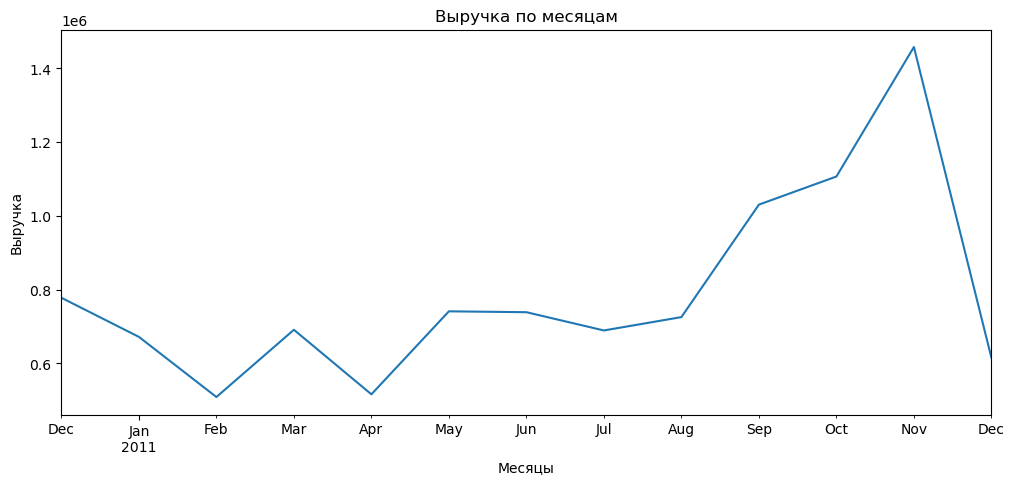

In [77]:
montly_revenue.plot(
    figsize = (12,5),
    title = 'Выручка по месяцам',
    xlabel = 'Месяцы',
    ylabel = 'Выручка'
)

In [78]:
dec_11 = db_final[
   (db_final['InvoiceDate'].dt.month == 12) &
    (db_final['InvoiceDate'].dt.year == 2011)
]
print(dec_11['InvoiceDate'].max())

2011-12-09 12:50:00


In [79]:
# Инсайт 2: В конце года динамика продаж увеличивается, достигая пика в ноябре-декабре, практический в 2 раз. Данные за декабрь не полные (в данных месяц заканчивается 9.12.2011), поэтому спад в графике не релевантен.

In [80]:
# Шаг 4. Смотрим Топ-10 товаров по выручке и ТОп-5 стран по объему заказов
top_10 = db_final.groupby(db_final['Description'])['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_10)

Description
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66964.99
PAPER CHAIN KIT 50'S CHRISTMAS         64952.29
ASSORTED COLOUR BIRD ORNAMENT          59094.93
CHILLI LIGHTS                          54117.76
Name: Revenue, dtype: float64


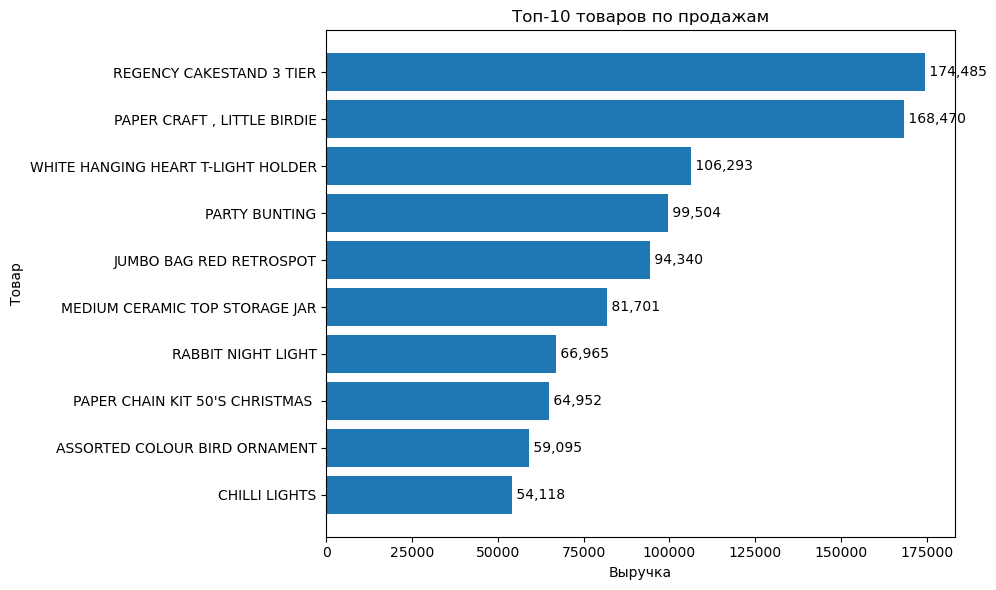

In [81]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_10.index, top_10.values)
ax.set_xlabel('Выручка')
ax.set_ylabel('Товар')
ax.set_title('Топ-10 товаров по продажам')
for i, value in enumerate(top_10.values):
    ax.text(value, i, f' {value:,.0f}', va='center')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [82]:
top_5_countrys = db_final.groupby(db_final['Country'])['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_5_countrys)

Country
United Kingdom    8748250.023
Netherlands        283889.340
EIRE               271164.300
Germany            205569.890
France             184582.740
Name: Revenue, dtype: float64


In [83]:
df_returns_uk = db_final[db_final['Country'].astype(str) == ('United Kingdom')] 
uk_revenue = df_returns_uk['Revenue'].sum()
print(f'UK доля: {uk_revenue/net_revenue*100:.1f}%')

UK доля: 93.3%


Инсайт 1: Уровень возвратов составляет 8.7%, что вдвое ниже среднего по рынку (16.7%). Скорее всего связано это со специцикой продаваемого товара, стоимость его возврата сопоставима со стоимостью товара.
Инсайт 2: В конце года динамика продаж увеличивается, достигая пика в ноябре-декабре, практический в 2 раз. Данные за декабрь не полные (в данных месяц заканчивается 9.12.2011), поэтому спад в графике не релевантен.
Инсайт 3: Основаная доля рынка (93.3%) в магазине приходится на Соединенное Королевство, второе место за Нидерландами, третье за Нидерландами.